# 01 - Data Exploration

Explore the folder-based Kaggle FER-2013 dataset and confirm the target class distribution.


In [1]:
import sys
from pathlib import Path

print('Notebook Python:', sys.executable)
current = Path.cwd().resolve()
expected_python = None
for path in [current, *current.parents]:
    candidate = path / '.venv' / 'bin' / 'python'
    if candidate.exists():
        expected_python = candidate
        break

if expected_python and Path(sys.executable).resolve() != expected_python.resolve():
    print('WARNING: This notebook is not using the project .venv kernel.')
    print('Expected:', expected_python)
    print('In VS Code, select kernel: KidMood (.venv)')
else:
    print('Kernel check passed.')


Notebook Python: /home/daddy/.venv/bin/python
Kernel check passed.


In [2]:
from pathlib import Path
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / 'src' / 'data_processing.py').exists():
            return path
    raise FileNotFoundError('Could not find project root containing src/data_processing.py')

PROJECT_ROOT = find_project_root()
src_path = PROJECT_ROOT / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt

from data_processing import CLASS_DIRS, CLASS_NAMES, count_images_by_class, validate_directory_structure

raw_dir = PROJECT_ROOT / 'data' / 'raw'
validate_directory_structure(raw_dir)
print('Project root:', PROJECT_ROOT)
print('Dataset found:', raw_dir)
print('Target classes:', CLASS_NAMES)


Project root: /home/daddy/Desktop/_DEV/_SCHOOL/ITAI-1378_COMP-VISION/KidMood-Final-Project
Dataset found: /home/daddy/Desktop/_DEV/_SCHOOL/ITAI-1378_COMP-VISION/KidMood-Final-Project/data/raw
Target classes: ['Angry', 'Fear', 'Happy', 'Sad']


In [3]:
train_counts = count_images_by_class(raw_dir / 'train')
test_counts = count_images_by_class(raw_dir / 'test')

print('Train counts:')
for folder, label in zip(CLASS_DIRS, CLASS_NAMES):
    print(f'  {label}: {train_counts[folder]}')

print()
print('Test counts:')
for folder, label in zip(CLASS_DIRS, CLASS_NAMES):
    print(f'  {label}: {test_counts[folder]}')


Train counts:
  Angry: 3995
  Fear: 4097
  Happy: 7215
  Sad: 4830

Test counts:
  Angry: 958
  Fear: 1024
  Happy: 1774
  Sad: 1247


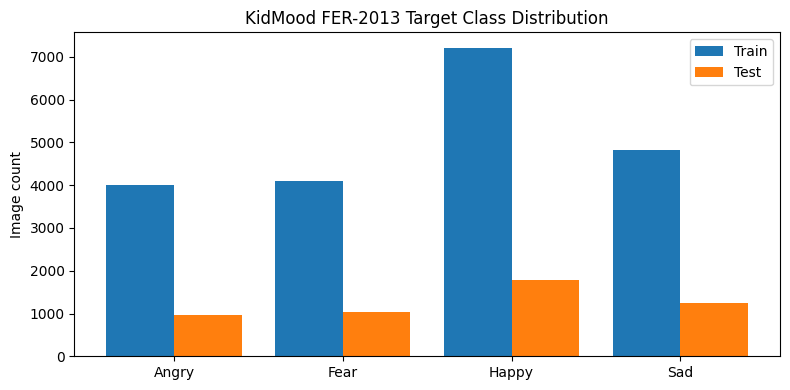

In [4]:
labels = CLASS_NAMES
train_values = [train_counts[folder] for folder in CLASS_DIRS]
test_values = [test_counts[folder] for folder in CLASS_DIRS]

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(labels))
ax.bar([i - 0.2 for i in x], train_values, width=0.4, label='Train')
ax.bar([i + 0.2 for i in x], test_values, width=0.4, label='Test')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Image count')
ax.set_title('KidMood FER-2013 Target Class Distribution')
ax.legend()
plt.tight_layout()
plt.show()


## Notes

The Kaggle dataset includes extra folders such as disgust, neutral, and surprise. This project intentionally loads only Angry, Fear, Happy, and Sad.
